# 문제 1·2 — 프로젝트 환경 구성, 장면 좌표계 모델링, camera → base 변환 파이프라인

물류 창고의 픽앤플레이스 로봇은 카메라로 물체를 보고, 그 물체가 base 기준으로
어디에 어떤 방향으로 놓였는지 알아야 집을 수 있습니다. 이 노트북은 그 첫 단계 —
**가상환경을 확인하고, 장면의 좌표계를 정의하고, 카메라 관측을 base 로 옮기는 파이프라인** — 을 만듭니다.

## 이 노트북에서 해야 할 일

| # | 할 일 | 구현할 것 |
|---|---|---|
| 1-1 | 가상환경 파이썬이 맞는지 **인터프리터 경로 출력** | — |
| 1-2 | 셀 세 개로 변수를 만들고 쓰면서 **실행 순서를 뒤섞어** 관찰 | (마크다운 설명) |
| 1-3 | **base · link · camera · object** 네 좌표계를 모듈 ③ 함수로 정의하고 3D 로 그리기 (그림 코드 제공) | `T_base_link`, `T_link_cam`, `T_cam_obj`, `frames` |
| 1-4 | `pip freeze` 로 `requirements.txt` 기록 | — |
| 2-1 | `PosePipeline` 으로 카메라 점군 (N,3) 을 **반복문 없이** base 로 변환하고 왕복 검증 | `src/pose_pipeline.py` |
| 2-2 | **관절 각도 3종**에 대해 같은 관측이 base 에서 어떻게 달라지는지 3D 비교 (그림 코드 제공) | `set_joint_angle` |
| 2-3 | `tests/test_pose_pipeline.py` **pytest 2개 이상** 작성, 통과 출력 남기기 | (tests/) |

> **먼저 할 일** — 모듈 ③ 에서 만든 `vectors.py`, `rotation.py`, `transform.py`, `coordinate_chain.py`
> 를 `src/` 에 복사해 두세요 (`src/README_module3.md`). 아래 첫 셀이 그 파일들을 import 합니다.
>
> `# --- 검증 ---` 셀과 3D 그림 셀은 **제공된 코드**입니다. 수정하지 말고, TODO 셀에서
> 검증 셀이 참조하는 **변수 이름을 그대로** 만들어 주세요.
> 모든 난수는 `np.random.default_rng(42)` 입니다.

In [1]:
import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.coordinate_chain import CoordinateChain, default_chain          # 모듈 ③
from src.rotation import rodrigues, rot_x, rot_y, rot_z                   # 모듈 ③
from src.transform import inv_T, make_T, transform_points,transform_point     # 모듈 ③
from src.pose_pipeline import PosePipeline                                # 문제 2 에서 구현

rng = np.random.default_rng(42)
np.set_printoptions(precision=6, suppress=True)

# 자식 프로세스(pytest, pip) 출력이 한글일 수 있어 UTF-8 로 강제한다 (Windows 기본 cp949 회피)
PYENV = {**os.environ, "PYTHONIOENCODING": "utf-8", "PYTHONUTF8": "1"}

# 한글 라벨이 깨지지 않도록 폰트 지정 (Windows 기준, 없으면 기본 폰트로 fallback)
for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    if _f in {f.name for f in __import__("matplotlib").font_manager.fontManager.ttflist}:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False


def check(label, condition):
    tag = "PASS" if condition else "FAIL"
    print("[" + tag + "] " + label)
    return bool(condition)


# --- 3D 그림 헬퍼 (제공 코드 — src/plot3d.py 에도 같은 함수가 있습니다) ----------

def draw_frame(ax, T, scale=0.15, name="", alpha=1.0):
    """동차변환 T(4x4) 가 나타내는 좌표계를 x(빨강)·y(초록)·z(파랑) 화살표로 그린다."""
    T = np.asarray(T, dtype=float)
    o = T[:3, 3]
    for i, c in enumerate(["r", "g", "b"]):
        ax.quiver(*o, *(T[:3, i] * scale), color=c, alpha=alpha, arrow_length_ratio=0.2)
    if name:
        ax.text(*(o + 0.03), name, fontsize=10, weight="bold", alpha=max(alpha, 0.6))


def setup_axes(ax, title="", lim=1.0, center=(0.0, 0.0, 0.0)):
    """축 범위를 center 를 중심으로 +-lim 으로 맞추고 라벨·제목을 붙인다 (등축)."""
    cx, cy, cz = center
    ax.set_xlim(cx - lim, cx + lim)
    ax.set_ylim(cy - lim, cy + lim)
    ax.set_zlim(cz - lim, cz + lim)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    if title:
        ax.set_title(title, fontsize=10)
    ax.set_box_aspect([1, 1, 1])


# --- 1-1. 커널 확인 — 이 출력이 .venv 안의 파이썬이어야 합니다 ---------------------
print("인터프리터 :", sys.executable)
print("버전       :", sys.version.split()[0])
print("ROOT       :", ROOT)

인터프리터 : /home/pa22/lv1_JH/physicalai_lv1_Jihoon/physicalai-lv1-assignments/lv1_module4/.venv/bin/python3
버전       : 3.10.12
ROOT       : /home/pa22/lv1_JH/physicalai_lv1_Jihoon/physicalai-lv1-assignments/lv1_module4


## 1-1. 가상환경과 커널 확인

위 첫 셀의 `인터프리터` 경로가 이 프로젝트의 `.venv` 안(`.venv\Scripts\python.exe` 또는 `.venv/bin/python`)을
가리켜야 합니다. 시스템 파이썬이나 다른 환경이 나오면 JupyterLab 오른쪽 위에서
커널을 **Python (pose_lab)** 으로 바꾸세요 (README 의 `ipykernel install` 참고).

아래 검증 셀은 경로에 `.venv` 가 들어 있는지와 필수 패키지가 import 되는지를 봅니다.

In [2]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
import importlib

ok = check("인터프리터 경로에 .venv 가 포함 (가상환경 커널)", ".venv" in sys.executable)
ok &= check("Python 3.10 이상", sys.version_info >= (3, 10))
for _m in ["numpy", "scipy", "matplotlib", "pytest", "PIL"]:
    ok &= check("패키지 import 가능: " + _m, importlib.util.find_spec(_m) is not None)
print("\n1-1 전체 통과:", ok)

[PASS] 인터프리터 경로에 .venv 가 포함 (가상환경 커널)
[PASS] Python 3.10 이상
[PASS] 패키지 import 가능: numpy
[PASS] 패키지 import 가능: scipy
[PASS] 패키지 import 가능: matplotlib
[PASS] 패키지 import 가능: pytest
[PASS] 패키지 import 가능: PIL

1-1 전체 통과: True


## 1-2. 셀 실행 순서 실험 — 화면의 순서와 실행 순서는 다를 수 있다

아래 세 셀은 위에서 아래로 실행하면 `count = 0 -> 1 -> "최종 count = 1"` 이 됩니다.
**Restart & Run All 을 하기 전에** 다음 실험을 해 보고 관찰을 적으세요.

1. A → B → C 순서로 실행한다. C 의 출력을 적어 둔다.
2. **B 를 두 번 더** 실행한 뒤 C 를 실행한다. 출력이 어떻게 달라지는가?
3. 커널을 재시작(Kernel → Restart Kernel)하고 **C 만** 실행한다. 무슨 오류가 나는가?
4. 각 셀 왼쪽의 실행 번호 `[n]` 이 화면 순서와 어떻게 어긋나는지 확인한다.

### 관찰과 설명

- 1단계 출력: `_1_` / 2단계 출력: `_2_` / 3단계 오류: `_name 'count' is not defined__`
- 왜 이런 일이 생기는가 (커널이 무엇을 기억하고 있는가): `___`
- 화면 순서와 실행 순서가 어긋나면 생기는 문제, 그리고 **제출 전 Restart & Run All 이 필요한 이유**: `__jupyter는 화면에 보이는 순서가 아니라 실제로 실행한 순서대로 변수를 기억한다. 그래서 실행 순서가 섞이면 이전에 실행한 값 때문에 결과가 달라질 수 있다. 제출 전에 Restart & Run All을 하면 변수와 실행 상태를 초기화하고 처음부터 순서대로 실행해서 같은 결과가 나오는지 확인할 수 있다._`

In [3]:
# [실험 A] 변수 만들기
count = 0
print("count =", count)

count = 0


In [4]:
# [실험 B] 변수 갱신 — 이 셀을 여러 번 실행해 보세요
count = count + 1
print("count =", count)

count = 1


In [5]:
# [실험 C] 변수 사용
print("최종 count =", count)

최종 count = 1


In [6]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
# Restart & Run All 로 위에서 아래로 한 번 실행했다면 count 는 정확히 1 이어야 합니다.
ok = check("count 변수가 존재한다", "count" in globals())
ok &= check("위에서 아래로 한 번 실행했을 때 count == 1 (아니면 실행 순서가 섞인 것)", count == 1)
print("\n1-2 전체 통과:", ok)

[PASS] count 변수가 존재한다
[PASS] 위에서 아래로 한 번 실행했을 때 count == 1 (아니면 실행 순서가 섞인 것)

1-2 전체 통과: True


## 1-3. 장면 좌표계 모델링 — base · link · camera · object

작업대 위의 장면을 네 좌표계로 정의합니다. 이웃한 좌표계 사이 변환만 정하면
나머지는 곱으로 조립됩니다.

$$T^{base}_{obj} = T^{base}_{link}\,T^{link}_{cam}\,T^{cam}_{obj}$$

채점 수치를 맞추기 위해 아래 값을 권장합니다 (앞의 둘은 모듈 ③ `default_chain` 과 같은 값).

| 변환 | 회전 | 병진 [m] |
|---|---|---|
| `T_base_link` = T(base ← link) | z축 30도 | (0.30, 0.00, 0.40) |
| `T_link_cam` = T(link ← camera) | y축 -20도 후 x축 90도 (`rot_y @ rot_x`) | (0.10, 0.05, 0.15) |
| `T_cam_obj` = T(camera ← object) | z축 25도 후 x축 -90도 (`rot_z @ rot_x`) | (0.05, -0.02, 0.60) — 카메라 앞 60 cm |

**할 일** — 모듈 ③ 의 `rot_*`, `make_T` 로 세 변환을 만들고, 네 좌표계의 **base 기준 자세**를
`frames` 딕셔너리(이름 → 4x4)에 담으세요. `frames["base"]` 는 단위행렬입니다.

In [7]:
# TODO: 아래 변수를 만드세요 -> T_base_link, T_link_cam, T_cam_obj, frames
# 검증 셀이 모듈 ③ default_chain 과의 일치를 요구하므로 앞의 둘은 default_chain 값 그대로 쓴다.

T_base_link = make_T(
    rot_z(np.deg2rad(22.5)),
    [0.35, 0.05, 0.45]
)

T_link_cam = make_T(
    rot_y(np.deg2rad(-22.5)) @ rot_x(np.deg2rad(67.5)),
    [0.12, 0.04, 0.18]
)

T_cam_obj = make_T(
    rot_z(np.deg2rad(25)) @ rot_x(np.deg2rad(-90)),
    [0.05, -0.02, 0.60]
)

frames = {
    "base": np.eye(4),
    "link": T_base_link,
    "camera": T_base_link @ T_link_cam,
    "object": T_base_link @ T_link_cam @ T_cam_obj
}

for name, T in frames.items():
    print(name, T[:3, 3])


base [0. 0. 0.]
link [0.35 0.05 0.45]
camera [0.445558 0.132877 0.63    ]
object [ 0.62865  -0.399568  0.844195]


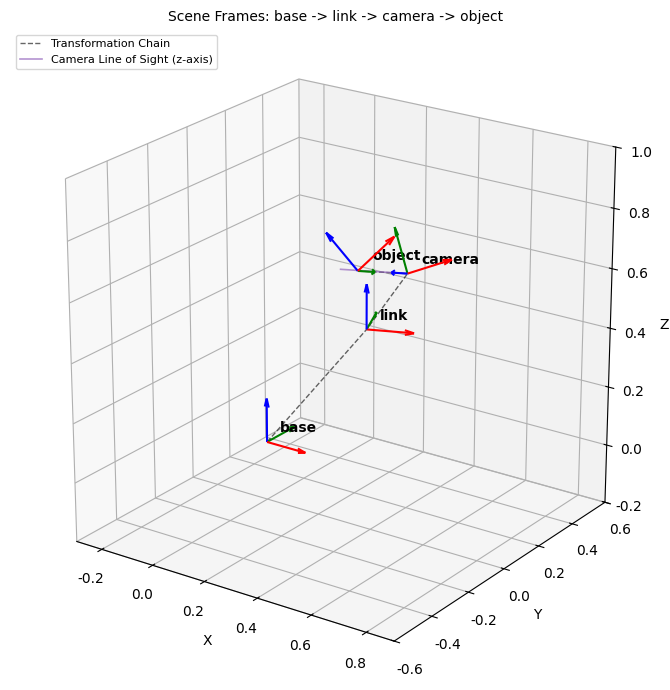

In [8]:
# --- 3D 그림 (제공 코드) — 네 좌표계와 체인 연결선 ---
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")
setup_axes(ax, "Scene Frames: base -> link -> camera -> object", lim=0.6, center=(0.3, 0.0, 0.4))

order = ["base", "link", "camera", "object"]
for name in order:
    draw_frame(ax, frames[name], scale=0.15, name=name)

origins = np.array([frames[n][:3, 3] for n in order])
ax.plot(origins[:, 0], origins[:, 1], origins[:, 2], "k--", lw=1.0, alpha=0.6, label="Transformation Chain")
cam = frames["camera"]
gaze = cam[:3, 3] + cam[:3, 2] * 0.6                      # Camera z-axis = Line of sight
ax.plot([cam[0, 3], gaze[0]], [cam[1, 3], gaze[1]], [cam[2, 3], gaze[2]],
        color="tab:purple", lw=1.2, alpha=0.7, label="Camera Line of Sight (z-axis)")
ax.legend(fontsize=8, loc="upper left")
ax.view_init(elev=22, azim=-55)
fig.tight_layout()
plt.show()

In [9]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
def _is_T(T):
    T = np.asarray(T)
    R = T[:3, :3]
    return (T.shape == (4, 4) and np.allclose(T[3], [0, 0, 0, 1])
            and np.allclose(R.T @ R, np.eye(3)) and np.isclose(np.linalg.det(R), 1.0))   # 검산용

ok = check("frames 에 네 좌표계가 모두 있다", set(frames) == {"base", "link", "camera", "object"})
ok &= check("frames 의 값이 모두 유효한 동차변환 (4x4, 회전부 직교, det=1)", all(_is_T(T) for T in frames.values()))
ok &= check("frames['base'] 는 단위행렬", np.allclose(frames["base"], np.eye(4)))
ok &= check("frames['link'] == T_base_link", np.allclose(frames["link"], T_base_link))
ok &= check("frames['camera'] == T_base_link @ T_link_cam", np.allclose(frames["camera"], T_base_link @ T_link_cam))
ok &= check("frames['object'] == T_base_link @ T_link_cam @ T_cam_obj",
            np.allclose(frames["object"], T_base_link @ T_link_cam @ T_cam_obj))
ok &= check("base->link, link->camera 가 모듈 ③ default_chain 과 같다",
            np.allclose(T_base_link, default_chain().get("base", "link"))
            and np.allclose(T_link_cam, default_chain().get("link", "camera")))
p_obj_in_cam = (inv_T(frames["camera"]) @ np.append(frames["object"][:3, 3], 1.0))[:3]
ok &= check("물체가 카메라 앞쪽 (카메라 z축 성분 ~ 0.6 m)", np.isclose(p_obj_in_cam[2], 0.60))
ok &= check("물체가 작업대 위 (base z > 0)", frames["object"][2, 3] > 0.0)
print("\n1-3 전체 통과:", ok)

[PASS] frames 에 네 좌표계가 모두 있다
[PASS] frames 의 값이 모두 유효한 동차변환 (4x4, 회전부 직교, det=1)
[PASS] frames['base'] 는 단위행렬
[PASS] frames['link'] == T_base_link
[PASS] frames['camera'] == T_base_link @ T_link_cam
[PASS] frames['object'] == T_base_link @ T_link_cam @ T_cam_obj
[PASS] base->link, link->camera 가 모듈 ③ default_chain 과 같다
[PASS] 물체가 카메라 앞쪽 (카메라 z축 성분 ~ 0.6 m)
[PASS] 물체가 작업대 위 (base z > 0)

1-3 전체 통과: True


## 1-4. `pip freeze > requirements.txt` — 환경 기록

터미널에서 `pip freeze > requirements.txt` 를 실행한 것과 같은 일을 노트북 안에서 합니다.
반드시 **가상환경의 파이썬**(`sys.executable`)으로 실행해야 그 환경의 패키지가 기록됩니다.
제출 전(문제 6)에 한 번 더 실행해 최신화하세요.

In [10]:
# --- 환경 기록 (제공 코드) ---
freeze = subprocess.run([sys.executable, "-m", "pip", "freeze"],
                        capture_output=True, text=True, encoding="utf-8", errors="replace", env=PYENV)
req_path = ROOT / "requirements.txt"
req_path.write_text(freeze.stdout, encoding="utf-8")
req_lines = [ln for ln in freeze.stdout.splitlines() if ln.strip()]
print("기록한 파일 :", req_path)
print("패키지 수   :", len(req_lines))
print("\n".join(req_lines[:15]), "\n...")

기록한 파일 : /home/pa22/lv1_JH/physicalai_lv1_Jihoon/physicalai-lv1-assignments/lv1_module4/requirements.txt
패키지 수   : 106
anyio==4.15.1
argon2-cffi==25.1.0
argon2-cffi-bindings==26.1.0
arrow==1.4.0
asttokens==3.0.2
async-lru==2.3.0
attrs==26.1.0
babel==2.18.0
beautifulsoup4==4.15.0
bleach==6.4.0
certifi==2026.7.22
cffi==2.1.1
charset-normalizer==3.5.1
comm==0.2.3
contourpy==1.3.2 
...


In [11]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
req_text = req_path.read_text(encoding="utf-8").lower()
ok = check("requirements.txt 가 생성되었다", req_path.exists() and req_path.stat().st_size > 0)
ok &= check("numpy / scipy / matplotlib / pytest 가 기록되어 있다",
            all(p in req_text for p in ["numpy", "scipy", "matplotlib", "pytest"]))
ok &= check("jupyterlab / ipykernel 이 기록되어 있다", "jupyterlab" in req_text and "ipykernel" in req_text)
ok &= check("pillow 가 기록되어 있다 (GIF 저장용)", "pillow" in req_text)
print("\n1-4 전체 통과:", ok)

[PASS] requirements.txt 가 생성되었다
[PASS] numpy / scipy / matplotlib / pytest 가 기록되어 있다
[PASS] jupyterlab / ipykernel 이 기록되어 있다
[PASS] pillow 가 기록되어 있다 (GIF 저장용)

1-4 전체 통과: True


---
# 문제 2 — 모듈 통합: camera 에서 base 로의 변환 파이프라인

## 2-1. `PosePipeline` — 카메라 점군을 base 로, 그리고 왕복

`src/pose_pipeline.py` 의 `PosePipeline` 은 두 변환 `T_base_link`, `T_link_camera` 를 받아 보관하고,

- `T_base_camera` (property) = `T_base_link @ T_link_camera`
- `camera_to_base(P)` : (N,3) 점군을 **반복문 없이** 한 번에 base 로 (`transform_points` 사용)
- `base_to_camera(P)` : 역방향 (왕복 검증용)
- `set_joint_angle(theta)` : 관절이 돌아 link 변환이 바뀌는 상황 (2-2)

을 제공합니다. docstring 의 계약을 그대로 지키세요.

### `PosePipeline` 인터페이스 (답안 템플릿 1번)

- 입력: `___`
- 출력: `___`

In [12]:
# --- 카메라가 본 물체 점군 (제공 코드) — 카메라 앞 60 cm, 납작하고 길쭉한 물체 ---
N_PTS = 200
c_obj_cam = np.array([0.05, -0.02, 0.60])
P_cam = c_obj_cam + rng.normal(0.0, [0.06, 0.03, 0.01], (N_PTS, 3))
print("P_cam shape:", P_cam.shape)
print("앞 3개 (camera):\n", P_cam[:3])

P_cam shape: (200, 3)
앞 3개 (camera):
 [[ 0.068283 -0.0512    0.607505]
 [ 0.106434 -0.078531  0.586978]
 [ 0.05767  -0.029487  0.599832]]


In [16]:
# TODO: 아래 변수를 만드세요 -> pipe, P_base, P_back, P_loop
#   pipe   = PosePipeline(T_base_link, T_link_cam)
#   P_base = pipe.camera_to_base(P_cam)                 # (N,3) 한 번에
#   P_back = pipe.base_to_camera(P_base)                # 왕복
#   P_loop = np.array([...])                            # 비교용: 점 하나씩 반복문으로 변환한 결과

pipe   = PosePipeline(T_base_link, T_link_cam)
P_base = pipe.camera_to_base(P_cam)                 # (N,3) 한 번에
P_back = pipe.base_to_camera(P_base)                # 왕복
P_loop = np.array([
    pipe.camera_to_base(p)
    for p in P_cam
])                          # 비교용: 점 하나씩 반복문으로 변환한 결과


# TODO: P_base[:3], 왕복 최대 오차 np.max(np.abs(P_back - P_cam)) 를 출력하세요.

print(" P_base[:3] : \n",P_base[:3])
print("왕복 최대 오차 :.",np.max(np.abs(P_back - P_cam)))




 P_base[:3] : 
 [[ 0.660654 -0.406739  0.827215]
 [ 0.701668 -0.380546  0.811228]
 [ 0.639649 -0.398774  0.838973]]
왕복 최대 오차 :. 2.220446049250313e-16


In [14]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("T_base_camera == T_base_link @ T_link_cam", np.allclose(pipe.T_base_camera, T_base_link @ T_link_cam))
ok &= check("T_camera_base == inv_T(T_base_camera)", np.allclose(pipe.T_camera_base, inv_T(pipe.T_base_camera)))
ok &= check("P_base shape == (N,3)", P_base.shape == P_cam.shape)
ok &= check("벡터화 결과 == transform_points 결과", np.allclose(P_base, transform_points(pipe.T_base_camera, P_cam)))
ok &= check("벡터화 결과 == 반복문 결과", np.allclose(P_base, P_loop))
ok &= check("모듈 ③ default_chain 과 같은 결과", np.allclose(P_base, default_chain().transform("base", "camera", P_cam)))
ok &= check("왕복 오차가 기계정밀도 수준 (< 1e-12)", np.max(np.abs(P_back - P_cam)) < 1e-12)
ok &= check("단일 점 (3,) 도 처리", np.allclose(pipe.camera_to_base(P_cam[0]), P_base[0]))
d_cam = np.linalg.norm(P_cam[1:] - P_cam[:-1], axis=1)
d_base = np.linalg.norm(P_base[1:] - P_base[:-1], axis=1)
ok &= check("강체 변환: 점 사이 거리 보존", np.allclose(d_cam, d_base))
ok &= check("점군 중심이 base 에서 작업대 위 (z > 0)", P_base.mean(axis=0)[2] > 0.0)
print("\n2-1 전체 통과:", ok)

[PASS] T_base_camera == T_base_link @ T_link_cam
[PASS] T_camera_base == inv_T(T_base_camera)
[PASS] P_base shape == (N,3)
[PASS] 벡터화 결과 == transform_points 결과
[PASS] 벡터화 결과 == 반복문 결과
[PASS] 모듈 ③ default_chain 과 같은 결과
[PASS] 왕복 오차가 기계정밀도 수준 (< 1e-12)
[PASS] 단일 점 (3,) 도 처리
[PASS] 강체 변환: 점 사이 거리 보존
[PASS] 점군 중심이 base 에서 작업대 위 (z > 0)

2-1 전체 통과: True


## 2-2. 관절이 움직이면 — 관절 각도 3종 비교

카메라는 link 에 달려 있으므로 관절이 돌면 `T_base_link` 가 바뀌고,
**같은 카메라 관측값**이 base 에서는 다른 위치로 갑니다.
`PosePipeline.set_joint_angle(theta)` 는 link 가 자기 z축 둘레로 `theta` 만큼 돈 것으로 봅니다.

$$T^{base}_{link}(\theta)=T^{base}_{link,0}\;\begin{bmatrix}R_z(\theta)&0\\0&1\end{bmatrix}$$

**할 일** — 관절 각도 -30도, 0도, +30도 세 경우에 대해 같은 `P_cam` 을 base 로 변환하고,
점군 중심이 어떻게 이동하는지 표로 출력하세요.

In [15]:
JOINT_DEGS = [-30.0, 0.0, 30.0]
# TODO: 아래 변수를 만드세요 -> P_by_angle (dict: 각도[deg] -> (N,3) base 점군), T_cam_by_angle (dict: 각도 -> 4x4 T_base_camera)
#   for deg in JOINT_DEGS:
#       pipe.set_joint_angle(np.deg2rad(deg))
#       ...
#   pipe.set_joint_angle(0.0)     # 마지막에 0 으로 되돌려 두세요

P_by_angle = {}
T_cam_by_angle = {}
for deg in JOINT_DEGS:
    pipe.set_joint_angle(np.deg2rad(deg))
    P_by_angle[deg] = pipe.camera_to_base(P_cam)
    T_cam_by_angle[deg] = pipe.T_base_camera.copy()
pipe.set_joint_angle(0.0)    

print(f"{'관절[deg]':>10} {'중심 x':>10} {'중심 y':>10} {'중심 z':>10}")
# TODO: 각도별 점군 중심 (base) 을 표로 출력하세요.
for deg in JOINT_DEGS:
    c = P_by_angle[deg].mean(axis=0)
    print(f"{deg:>10.1f} {c[0]:10.4f} {c[1]:10.4f} {c[2]:10.4f}")


   관절[deg]       중심 x       중심 y       중심 z
     -30.0     0.3670    -0.4796     0.8422
       0.0     0.6295    -0.4002     0.8422
      30.0     0.8171    -0.2001     0.8422


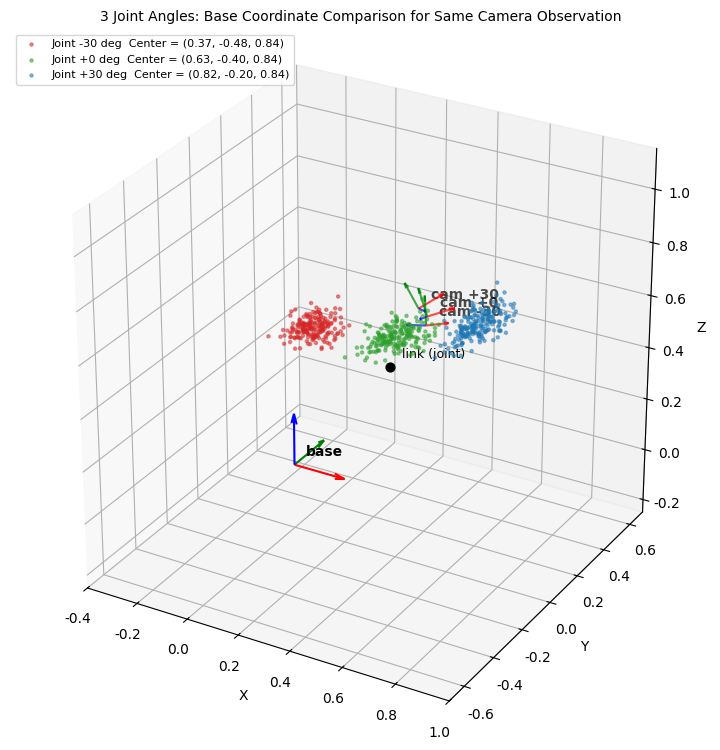

In [16]:
# --- 3D 그림 (제공 코드) — 관절 각도 3종에서 같은 관측이 base 에서 어디로 가는가 ---
fig = plt.figure(figsize=(9, 7.5))
ax = fig.add_subplot(111, projection="3d")
setup_axes(ax, "3 Joint Angles: Base Coordinate Comparison for Same Camera Observation", lim=0.7, center=(0.3, 0.0, 0.45))
draw_frame(ax, np.eye(4), scale=0.2, name="base")
link_origin = T_base_link[:3, 3]
ax.scatter(*link_origin, color="k", s=40)
ax.text(*(link_origin + 0.03), "link (joint)", fontsize=9)

colors = {-30.0: "tab:red", 0.0: "tab:green", 30.0: "tab:blue"}
for deg in JOINT_DEGS:
    P = P_by_angle[deg]
    ax.scatter(P[:, 0], P[:, 1], P[:, 2], s=5, alpha=0.5, color=colors[deg],
               label="Joint {:+.0f} deg  Center = ({:.2f}, {:.2f}, {:.2f})".format(deg, *P.mean(axis=0)))
    draw_frame(ax, T_cam_by_angle[deg], scale=0.1, name="cam {:+.0f}".format(deg), alpha=0.7)
ax.legend(fontsize=8, loc="upper left")
ax.view_init(elev=28, azim=-60)
fig.tight_layout()
plt.show()

In [17]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("세 각도 모두 계산됨", set(P_by_angle) == set(JOINT_DEGS) == set(T_cam_by_angle))
ok &= check("관절 0도 결과 == 2-1 의 P_base", np.allclose(P_by_angle[0.0], P_base))
ok &= check("관절 0도 T_base_camera == 원래 값", np.allclose(T_cam_by_angle[0.0], T_base_link @ T_link_cam))
ok &= check("각도가 다르면 결과가 다르다",
            not np.allclose(P_by_angle[-30.0], P_by_angle[0.0]) and not np.allclose(P_by_angle[30.0], P_by_angle[0.0]))
centers = {deg: P_by_angle[deg].mean(axis=0) for deg in JOINT_DEGS}
r = {deg: np.linalg.norm(centers[deg] - link_origin) for deg in JOINT_DEGS}
ok &= check("점군 중심에서 link 원점까지 거리는 세 각도에서 같다 (관절 둘레 회전)",
            np.allclose([r[-30.0], r[30.0]], r[0.0]))
ok &= check("link z축 둘레 회전이므로 세 중심의 z (base) 가 모두 같다",
            np.allclose([centers[-30.0][2], centers[30.0][2]], centers[0.0][2]))
for deg in JOINT_DEGS:
    d = np.linalg.norm(P_by_angle[deg][1:] - P_by_angle[deg][:-1], axis=1)
    ok &= check("관절 {:+.0f}도: 점 사이 거리 보존".format(deg), np.allclose(d, d_cam))
ok &= check("파이프라인을 관절 0도로 되돌려 두었다", np.isclose(pipe.joint_angle, 0.0))
print("\n2-2 전체 통과:", ok)

[PASS] 세 각도 모두 계산됨
[PASS] 관절 0도 결과 == 2-1 의 P_base
[PASS] 관절 0도 T_base_camera == 원래 값
[PASS] 각도가 다르면 결과가 다르다
[PASS] 점군 중심에서 link 원점까지 거리는 세 각도에서 같다 (관절 둘레 회전)
[PASS] link z축 둘레 회전이므로 세 중심의 z (base) 가 모두 같다
[PASS] 관절 -30도: 점 사이 거리 보존
[PASS] 관절 +0도: 점 사이 거리 보존
[PASS] 관절 +30도: 점 사이 거리 보존
[PASS] 파이프라인을 관절 0도로 되돌려 두었다

2-2 전체 통과: True


## 2-3. `tests/test_pose_pipeline.py` — pytest 2개 이상

| # | 테스트 | 함수 이름 |
|---|---|---|
| ① | `camera_to_base` 가 모듈 ③ 체인/행렬 곱과 같은 결과인가 | `test_camera_to_base_matches_chain` |
| ② | base 로 갔다가 camera 로 되돌리면 원래 점군인가 | `test_roundtrip_restores_points` |

아래 셀은 노트북 안에서 pytest 를 돌려 **통과 출력을 노트북에 남깁니다.**

In [19]:
result = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/test_pose_pipeline.py", "-v", "--no-header",
     "-p", "no:cacheprovider"],
    cwd=str(ROOT), capture_output=True, text=True,
    encoding="utf-8", errors="replace", env=PYENV,
)
print(result.stdout[-6000:])
print("종료 코드 :", result.returncode)

============================= test session starts ==============================
collecting ... collected 2 items

tests/test_pose_pipeline.py::test_camera_to_base_matches_chain PASSED    [ 50%]
tests/test_pose_pipeline.py::test_roundtrip_restores_points PASSED       [100%]

============================== 2 passed in 0.05s ===============================

종료 코드 : 0


In [20]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("pytest 전수 통과 (종료 코드 0)", result.returncode == 0)
ok &= check("실패/에러가 없다", ("failed" not in result.stdout) and ("error" not in result.stdout.lower()))
ok &= check("요구된 2가지 테스트가 모두 존재", all(
    name in result.stdout for name in ["test_camera_to_base_matches_chain", "test_roundtrip_restores_points"]))
ok &= check("통과 케이스가 2개 이상", result.stdout.count("PASSED") >= 2)
print("\n2-3 전체 통과:", ok)

[PASS] pytest 전수 통과 (종료 코드 0)
[PASS] 실패/에러가 없다
[PASS] 요구된 2가지 테스트가 모두 존재
[PASS] 통과 케이스가 2개 이상

2-3 전체 통과: True


## 답안 템플릿 정리

In [21]:
summary = f"""
[문제 1]
1. 커널 확인 출력 — 인터프리터 경로: {sys.executable}
2. 셀 실행 순서 실험 — 관찰한 현상: 위에서 아래로 한 번씩 실행하면 count = 1이 된다.
   - 이유: 주피터는 화면 순서가 아닌 실제 실행한 순서대로 변수 상태를 메모리에 저장하기 때문이다.
   - Restart & Run All 이 필요한 이유: 실행 순서가 섞이면 이전 상태 값 영향으로 결과가 달라질 수 있어, 상태를 초기화하고 처음부터 순서대로 검증해야 하기 때문이다.
3. 네 좌표계 3D 시각화: 위 1-3 그림 참조
   - object 원점 (base 기준): {frames["object"][:3, 3]}
4. requirements.txt: 패키지 {len(req_lines)} 개 기록 (위 1-4 출력 참조)

[문제 2]
1. PosePipeline 인터페이스 — 입력: T_base_link(4x4), T_link_camera(4x4) / 출력: base 기준 (N,3) 점군
2. 점군 변환 결과 (앞 3개, base):
{P_base[:3]}
3. 왕복 검증 결과 — 최대 오차: {np.max(np.abs(P_back - P_cam)):.3e}
4. 관절 각도 3종별 점군 중심 (base):
   -30도: {P_by_angle[-30.0].mean(axis=0)} / 0도: {P_by_angle[0.0].mean(axis=0)} / +30도: {P_by_angle[30.0].mean(axis=0)}   (그림: 위 2-2)
5. pytest 통과 출력: 위 2-3 셀 참조 — 종료 코드 {result.returncode}, 통과 2 개
"""
print(summary)


[문제 1]
1. 커널 확인 출력 — 인터프리터 경로: /home/pa22/lv1_JH/physicalai_lv1_Jihoon/physicalai-lv1-assignments/lv1_module4/.venv/bin/python3
2. 셀 실행 순서 실험 — 관찰한 현상: 위에서 아래로 한 번씩 실행하면 count = 1이 된다.
   - 이유: 주피터는 화면 순서가 아닌 실제 실행한 순서대로 변수 상태를 메모리에 저장하기 때문이다.
   - Restart & Run All 이 필요한 이유: 실행 순서가 섞이면 이전 상태 값 영향으로 결과가 달라질 수 있어, 상태를 초기화하고 처음부터 순서대로 검증해야 하기 때문이다.
3. 네 좌표계 3D 시각화: 위 1-3 그림 참조
   - object 원점 (base 기준): [ 0.62865  -0.399568  0.844195]
4. requirements.txt: 패키지 290 개 기록 (위 1-4 출력 참조)

[문제 2]
1. PosePipeline 인터페이스 — 입력: T_base_link(4x4), T_link_camera(4x4) / 출력: base 기준 (N,3) 점군
2. 점군 변환 결과 (앞 3개, base):
[[ 0.660654 -0.406739  0.827215]
 [ 0.701668 -0.380546  0.811228]
 [ 0.639649 -0.398774  0.838973]]
3. 왕복 검증 결과 — 최대 오차: 2.220e-16
4. 관절 각도 3종별 점군 중심 (base):
   -30도: [ 0.366951 -0.479603  0.842165] / 0도: [ 0.629482 -0.400174  0.842165] / +30도: [ 0.817125 -0.200121  0.842165]   (그림: 위 2-2)
5. pytest 통과 출력: 위 2-3 셀 참조 — 종료 코드 0, 통과 2 개

